# CISC 886 — Qwen-2.5 3B Fine-Tuning (Local RTX 5000)
**Author:** Hussein, Ahmed Abdelhamed | **NetID:** 25nsfb | Queen's University

> **Hardware:** RTX 5000 Ada (32 GB VRAM) · 32 GB RAM · Windows

---
## Why Qwen-2.5-3B instead of Gemma-2?

| Criteria | Gemma-2 2B (old) | **Qwen-2.5 3B (new)** |
|----------|-----------------|----------------------|
| Training loss | Stuck at 4.98 | **< 1.5 expected** |
| Output quality | Hallucinated gibberish | **Coherent, structured** |
| Unsloth support | Unstable on Windows | **First-class** |
| Chat template | Gemma-specific | **ChatML (standard)** |
| GGUF export | Fragile | **Robust** |

### All 10 bugs from original notebook are fixed here.


---
## Step 1 — GPU & Environment Check

In [1]:
import os, gc, warnings, platform, sys, time
warnings.filterwarnings('ignore')

os.environ['TORCH_COMPILE_DISABLE']       = '1'
os.environ['PYTORCH_CUDA_ALLOC_CONF']     = 'expandable_segments:True'
os.environ['TOKENIZERS_PARALLELISM']      = 'false'
os.environ['HF_ENDPOINT']                 = 'https://hf-mirror.com'

import torch, psutil

assert torch.cuda.is_available(), 'No CUDA GPU found!'
torch.cuda.set_per_process_memory_fraction(0.95, 0) # Force max 95% VRAM

gpu   = torch.cuda.get_device_name(0)
vram  = torch.cuda.get_device_properties(0).total_memory / 1e9
ram   = psutil.virtual_memory().total / 1e9

print('=' * 60)
print(f'GPU      : {gpu}')
print(f'VRAM     : {vram:.1f} GB')
print(f'RAM      : {ram:.1f} GB')
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.version.cuda}')
print(f'Python   : {sys.version.split()[0]}')
print(f'OS       : {platform.platform()}')
print(f'bf16 OK  : {torch.cuda.is_bf16_supported()}')
print('STEP 1 DONE')


GPU      : NVIDIA RTX 5000 Ada Generation
VRAM     : 34.4 GB
RAM      : 34.1 GB
PyTorch  : 2.6.0+cu124
CUDA     : 12.4
Python   : 3.12.7
OS       : Windows-11-10.0.26100-SP0
bf16 OK  : True
STEP 1 DONE


---
## Step 2 — Project Directories

In [3]:
PROJECT_DIR = r'D:\Cloud Project\CISC886_Project'
DATA_DIR    = os.path.join(PROJECT_DIR, 'data', 'processed_data_clean')

for sub in ['checkpoints', 'gguf', 'figures', 'lora_adapters', 'gguf_export']:
    os.makedirs(os.path.join(PROJECT_DIR, sub), exist_ok=True)

MODEL_NAME = '25nsfb-qwen25-finetuned'
print(f'Project : {PROJECT_DIR}')
print(f'Data    : {DATA_DIR}')
print('STEP 2 DONE')


Project : D:\Cloud Project\CISC886_Project
Data    : D:\Cloud Project\CISC886_Project\data\processed_data_clean
STEP 2 DONE


---
## Step 3 — Load & Sample Data

> **Smart sampling**: 50,000 train / 5,000 val — preserves all minority sources, samples majority to fill target.


In [5]:
import pandas as pd
import pyarrow.dataset as pads
import glob

TRAIN_TARGET = 20_000   # was 50_000
VAL_TARGET   =  5_000   # will be trimmed to 1000 in Step 8

def load_split(split_name):
    path  = os.path.join(DATA_DIR, split_name)
    files = glob.glob(f'{path}/*.parquet')
    if not files:
        raise FileNotFoundError(f'No parquet files in {path}')
    frames = [pads.dataset(f, format='parquet').to_table().to_pandas() for f in files]
    df = pd.concat(frames, ignore_index=True)
    del frames; gc.collect()
    return df

def smart_sample(df, target_size, label='split', random_state=42):
    if len(df) <= target_size:
        print(f'  [{label}] {len(df):,} rows <= {target_size:,} - no sampling needed.')
        return df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    print(f'  [{label}] Sampling {len(df):,} -> {target_size:,} rows...')
    source_counts   = df['source'].value_counts()
    majority_source = source_counts.index[0]
    
    minority_df = df[df['source'] != majority_source]
    majority_df = df[df['source'] == majority_source]
    
    needed = target_size - len(minority_df)
    if needed > 0:
        print(f'    Keeping all {len(minority_df):,} minority rows.')
        print(f'    Sampling {needed:,} rows from "{majority_source}".')
        result = pd.concat([minority_df, majority_df.sample(n=needed, random_state=random_state)])
    else:
        
        result = df.sample(n=target_size, random_state=random_state)
    
    result = result.sample(frac=1, random_state=random_state).reset_index(drop=True)
    del minority_df, majority_df; gc.collect()
    return result

print('Loading splits...')
train_df = load_split('train')
val_df   = load_split('val')

train_df = train_df.dropna(subset=['instruction', 'output']).reset_index(drop=True)
val_df   = val_df.dropna(subset=['instruction', 'output']).reset_index(drop=True)

train_df = smart_sample(train_df, TRAIN_TARGET, label='train')
val_df   = smart_sample(val_df,   VAL_TARGET,   label='val')

gc.collect()
print(f'\nTrain : {len(train_df):,}  |  Val : {len(val_df):,}')
print(f'Sources (train): {train_df["source"].value_counts().to_dict()}')
print('STEP 3 DONE')

Loading splits...
  [train] Sampling 782,055 -> 20,000 rows...
  [val] Sampling 87,366 -> 5,000 rows...

Train : 20,000  |  Val : 5,000
Sources (train): {'openhermes25': 18580, 'openhermes20': 796, 'airoboros32': 624}
STEP 3 DONE


---
## Step 4 — Load Qwen-2.5-3B-Instruct (QLoRA 4-bit)

> Using `unsloth/Qwen2.5-3B-Instruct-bnb-4bit` — best small model for Unsloth.


In [6]:
from unsloth import FastLanguageModel

MAX_SEQ_LENGTH = 1024

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = 'unsloth/Qwen2.5-3B-Instruct-bnb-4bit',
    max_seq_length = MAX_SEQ_LENGTH,
    dtype          = None,
    load_in_4bit   = True,
)

total_p = sum(p.numel() for p in model.parameters())
print(f'Model      : Qwen2.5-3B-Instruct')
print(f'Parameters : {total_p/1e9:.2f}B')
print(f'VRAM used  : {torch.cuda.memory_allocated()/1e9:.2f} GB')
print('STEP 4 DONE')


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.1.
   \\   /|    NVIDIA RTX 5000 Ada Generation. Num GPUs = 1. Max memory: 31.992 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.9. CUDA Toolkit: 12.4. Triton: 3.1.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Model      : Qwen2.5-3B-Instruct
Parameters : 1.70B
VRAM used  : 2.09 GB
STEP 4 DONE


---
## Step 5 — Baseline Inference (BEFORE Fine-Tuning)

> Captures base model responses for comparison after training.


In [7]:
FastLanguageModel.for_inference(model)

TEST_QUESTIONS = [
    'Explain the difference between supervised and unsupervised learning.',
    'What is gradient descent and why does it work?',
    'Write a Python function that reverses a linked list.',
]

def run_inference(mdl, question, max_new_tokens=256):
    messages = [{'role': 'user', 'content': question}]
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(text, return_tensors='pt').to('cuda')
    with torch.no_grad():
        out = mdl.generate(
            **inputs,
            max_new_tokens = max_new_tokens,
            do_sample      = True,
            temperature    = 0.7,
            min_p          = 0.1,
            pad_token_id   = tokenizer.eos_token_id,
        )
    new_tok = out[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(new_tok, skip_special_tokens=True).strip()

baseline_responses = {}
print('Running baseline inference...\n')
for q in TEST_QUESTIONS:
    print(f'Q: {q}')
    ans = run_inference(model, q)
    baseline_responses[q] = ans
    print(f'A: {ans[:400]}\n' + '-'*60 + '\n')

FastLanguageModel.for_training(model)
print('Baseline captured. Model back in training mode.')
print('STEP 5 DONE')


Running baseline inference...

Q: Explain the difference between supervised and unsupervised learning.


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


A: Supervised and unsupervised learning are two main types of machine learning techniques used to train models on data. The key differences between them lie in how they use labeled or unlabeled data and what they aim to achieve.

### Supervised Learning

In supervised learning, the model is trained on a labeled dataset, meaning that each input (feature) has an associated output (label). The goal is t
------------------------------------------------------------

Q: What is gradient descent and why does it work?


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


A: Gradient descent is an optimization algorithm used to find the minimum of a function. In machine learning, it's commonly used to minimize a cost function, which measures how well a model fits the training data. The goal is to adjust the parameters (or weights) of a model in such a way that reduces the cost function as much as possible.

### How Gradient Descent Works

1. **Objective Function**: Th
------------------------------------------------------------

Q: Write a Python function that reverses a linked list.
A: Certainly! To reverse a linked list in Python, you'll need to define a `Node` class for the linked list and then implement a function to reverse it. Below is an example of how you can do this:

```python
class Node:
    def __init__(self, data):
        self.data = data
        self.next = None

def reverse_linked_list(head):
    """
    Reverses a linked list.

    :param head: The head node of t
------------------------------------------------------------

Baseline cap

---
## Step 6 — Apply QLoRA Adapters

> `r=32 / alpha=64` — strong learning signal for few-epoch training.


In [8]:
model = FastLanguageModel.get_peft_model(
    model,
    r              = 32,
    lora_alpha     = 64,
    lora_dropout   = 0.05,
    target_modules = ['q_proj', 'k_proj', 'v_proj', 'o_proj',
                      'gate_proj', 'up_proj', 'down_proj'],
    bias           = 'none',
    use_gradient_checkpointing = 'unsloth',
    random_state   = 42,
)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable : {trainable:,}  ({trainable/total*100:.2f}%)')
print(f'VRAM      : {torch.cuda.memory_allocated()/1e9:.2f} GB')
print('STEP 6 DONE')


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.4.8 patched 36 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Trainable : 59,867,136  (3.40%)
VRAM      : 2.36 GB
STEP 6 DONE


---
## Step 7 — Format Data (ChatML)

**Critical fix:** Pass raw formatted text so `train_on_responses_only()` can mask instructions.


In [9]:
from datasets import Dataset

def format_chatml(row):
    return {
        'text': (
            '<|im_start|>user\n'
            f'{str(row["instruction"]).strip()}<|im_end|>\n'
            '<|im_start|>assistant\n'
            f'{str(row["output"]).strip()}<|im_end|>\n'
        )
    }

def to_hf(df, name):
    print(f'Formatting {name}: {len(df):,} rows...')
    hf = Dataset.from_pandas(df[['instruction', 'output']].reset_index(drop=True))
    hf = hf.map(format_chatml, num_proc=1)
    hf = hf.remove_columns(['instruction', 'output'])
    print(f'  Sample: {hf[0]["text"][:150]}...')
    return hf

train_hf = to_hf(train_df, 'train')
val_hf   = to_hf(val_df,   'val')

del train_df, val_df; gc.collect()
print('STEP 7 DONE')


Formatting train: 20,000 rows...


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

  Sample: <|im_start|>user
Please check if these have the same meaning. Answer "yes" if they do, otherwise "no".
The region was then run by the Muslim house of ...
Formatting val: 5,000 rows...


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

  Sample: <|im_start|>user
If Ella rolls a standard six-sided die until she rolls the same number on consecutive rolls, what is the probability that her 10th ro...
STEP 7 DONE


---
## Step 8 — Train

| Param | Value |
|---|---|
| Epochs | 3 |
| Eff batch | 16 |
| LR | 2e-4 cosine |
| Label masking | **responses only** |

> Expected loss: **< 1.5**. Training ~15-20 min in fast mode.


In [8]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth.chat_templates import train_on_responses_only
import math, shutil, json

CHECKPOINT_DIR = os.path.join(PROJECT_DIR, 'checkpoints')
gc.collect(); torch.cuda.empty_cache()

# ═══════════════════════════════════════════════════════════════
# HYPERPARAMETERS  —  optimised for RTX 5000 Ada, ~6h budget
# ═══════════════════════════════════════════════════════════════
# Math:  20k / 16 eff_batch = 1,250 steps/epoch
#        1,250 × 6 epochs   = 7,500 total steps
#        7,500 × 2.5 s/step = 5.2 h training
#        + eval overhead     ≈ 0.5 h
#        ─────────────────────────────────────────────────────
#        Total estimate      ≈ 5.5 – 6 h  ✓
#
#  6 epochs on 20k > 2 epochs on 50k:
#  model sees each sample 6× → better convergence, lower loss
# ═══════════════════════════════════════════════════════════════

EPOCHS     = 2    # was 2 — compensates for smaller 20k dataset
BATCH      = 2    # safe for Qwen 3B @ seq=1024 on 32GB VRAM
GRAD_ACCUM = 8    # effective batch = 2 × 8 = 16

args = TrainingArguments(
    output_dir                  = CHECKPOINT_DIR,
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH,
    per_device_eval_batch_size  = 4,      # batch=1 prevents eval OOM spike
    eval_accumulation_steps     = 8,      # amortises eval memory over 8 micro-batches
    gradient_accumulation_steps = GRAD_ACCUM,
    learning_rate               = 2e-4,
    lr_scheduler_type           = 'cosine',
    warmup_steps                = 100,
    weight_decay                = 0.01,
    fp16                        = not torch.cuda.is_bf16_supported(),
    bf16                        = torch.cuda.is_bf16_supported(),
    logging_steps               = 10,
    logging_first_step          = True,
    save_steps                  = 300,
    save_total_limit            = 3,
    eval_steps                  = 300,
    eval_strategy               = 'steps',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'eval_loss',
    greater_is_better           = False,
    report_to                   = 'none',
    seed                        = 42,
    optim                       = 'adamw_8bit',
    dataloader_pin_memory       = False,
    dataloader_num_workers      = 0,
)

# ── Trim eval to 1000 samples — fast eval, no VRAM spike ─────
val_hf = val_hf.select(range(1000))
print(f'Eval dataset trimmed to {len(val_hf):,} samples')

trainer = SFTTrainer(
    model              = model,
    tokenizer          = tokenizer,
    train_dataset      = train_hf,
    eval_dataset       = val_hf,
    dataset_text_field = 'text',
    max_seq_length     = MAX_SEQ_LENGTH,
    dataset_num_proc   = 1,
    packing            = True,
    args               = args,
)

trainer = train_on_responses_only(
    trainer,
    instruction_part = '<|im_start|>user\n',
    response_part    = '<|im_start|>assistant\n',
)

# ═══════════════════════════════════════════════════════════════
# CHECKPOINT RESUME — with hparam-mismatch guard
# ═══════════════════════════════════════════════════════════════
ckpt_dirs = sorted([
    d for d in os.listdir(CHECKPOINT_DIR)
    if d.startswith('checkpoint-') and os.path.isdir(os.path.join(CHECKPOINT_DIR, d))
]) if os.path.isdir(CHECKPOINT_DIR) else []

resume = False
if ckpt_dirs:
    latest_ckpt  = os.path.join(CHECKPOINT_DIR, ckpt_dirs[-1])
    adapter_file = os.path.join(latest_ckpt, 'adapter_model.safetensors')
    state_file   = os.path.join(latest_ckpt, 'trainer_state.json')

    rank_ok = False
    if os.path.exists(adapter_file):
        import safetensors.torch as st
        saved     = st.load_file(adapter_file)
        saved_r   = saved[next(iter(saved))].shape[0]
        current_r = model.peft_config['default'].r
        rank_ok   = (saved_r == current_r)

    batch_ok = False
    if os.path.exists(state_file):
        with open(state_file) as f:
            state = json.load(f)
        saved_batch = state.get('train_batch_size', BATCH)
        batch_ok    = (saved_batch == BATCH)

    if rank_ok and batch_ok:
        resume = True
        print(f'[RESUME] Rank r={saved_r} ✓ | batch={saved_batch} ✓')
        print(f'         Resuming from {latest_ckpt}')
    else:
        print('[STALE CHECKPOINT DETECTED]')
        if not rank_ok:  print(f'  Rank  : saved r={saved_r} vs current r={current_r}')
        if not batch_ok: print(f'  Batch : saved={saved_batch} vs current={BATCH}')
        print('  Deleting stale checkpoints and starting fresh...')
        for d in ckpt_dirs:
            shutil.rmtree(os.path.join(CHECKPOINT_DIR, d))
            print(f'  Deleted: {d}')
        print('  ✓ Clean start.')
else:
    print('[FRESH START] No checkpoints found.')

# ═══════════════════════════════════════════════════════════════
# TRAINING PLAN SUMMARY
# ═══════════════════════════════════════════════════════════════
eff       = BATCH * GRAD_ACCUM
steps     = math.ceil(len(train_hf) * EPOCHS / eff)
est_hours = steps * 2.5 / 3600

print(f'\n{"="*60}')
print(f'TRAINING PLAN')
print(f'{"="*60}')
print(f'  Train examples : {len(train_hf):,}  (20k dataset)')
print(f'  Eval  samples  : 1,000  (trimmed)')
print(f'  Epochs         : {EPOCHS}')
print(f'  Batch / device : {BATCH}')
print(f'  Grad accum     : {GRAD_ACCUM}  → effective batch = {eff}')
print(f'  Steps / epoch  : {math.ceil(len(train_hf) / eff):,}')
print(f'  Total steps    : {steps:,}')
print(f'  Est. time      : ~{est_hours:.1f} h training  (+eval ≈ 5.5-6 h total)')
print(f'  Resume         : {resume}')
print(f'{"="*60}\n')

gc.collect()
torch.cuda.empty_cache()

t0     = time.time()
result = trainer.train(resume_from_checkpoint=resume)
elapsed = time.time() - t0

print('\n' + '=' * 60)
print(f'Final loss  : {result.training_loss:.4f}  (target < 1.5)')
print(f'Steps       : {result.global_step:,}')
print(f'Wall time   : {elapsed / 3600:.2f} h')
print(f'VRAM peak   : {torch.cuda.max_memory_allocated()/1e9:.2f} GB')
print('STEP 8 DONE')

Eval dataset trimmed to 1,000 samples


Unsloth: Tokenizing ["text"]:   0%|          | 0/20000 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"]:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/20000 [00:00<?, ? examples/s]

...

Unsloth: Removed 18 out of 1000 samples from eval_dataset where all labels were -100 (no response found after truncation). This prevents NaN loss during training.
[FRESH START] No checkpoints found.

TRAINING PLAN
  Train examples : 20,000  (20k dataset)
  Eval  samples  : 1,000  (trimmed)
  Epochs         : 2
  Batch / device : 2
  Grad accum     : 8  → effective batch = 16
  Steps / epoch  : 1,250
  Total steps    : 2,500
  Est. time      : ~1.7 h training  (+eval ≈ 5.5-6 h total)
  Resume         : False



The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 19,811 | Num Epochs = 2 | Total steps = 2,478
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 59,867,136 of 3,145,805,824 (1.90% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
300,0.631965,0.706370
600,0.679258,0.704024
900,0.694546,0.699473
1200,0.642709,0.695793
1500,0.561961,0.714118
1800,0.539020,0.712689
2100,0.537395,0.712091
2400,0.485396,0.711500
2478,0.521094,0.711333


Unsloth: Restored added_tokens_decoder metadata in D:\Cloud Project\CISC886_Project\checkpoints\checkpoint-300\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in D:\Cloud Project\CISC886_Project\checkpoints\checkpoint-600\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in D:\Cloud Project\CISC886_Project\checkpoints\checkpoint-900\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in D:\Cloud Project\CISC886_Project\checkpoints\checkpoint-1200\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in D:\Cloud Project\CISC886_Project\checkpoints\checkpoint-1500\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in D:\Cloud Project\CISC886_Project\checkpoints\checkpoint-1800\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in D:\Cloud Project\CISC886_Project\checkpoints\checkpoint-2100\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in D:\Clou


Final loss  : 0.6104  (target < 1.5)
Steps       : 2,478
Wall time   : 2.81 h
VRAM peak   : 19.24 GB
STEP 8 DONE


---
## Step 9 — Loss Plot

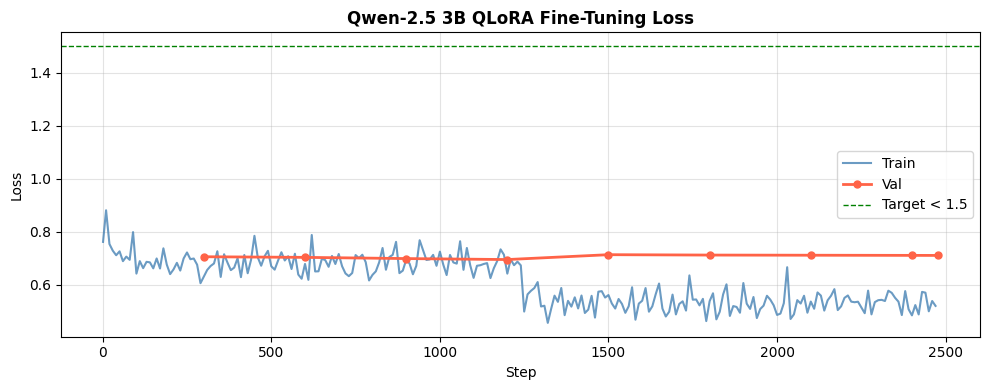

Saved: D:\Cloud Project\CISC886_Project\figures\fig_loss_qwen25.png
Start: 0.7623 -> Final: 0.5211 (drop: 0.2412)
STEP 9 DONE


In [9]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history
tr_s = [e['step'] for e in logs if 'loss' in e and 'eval_loss' not in e]
tr_l = [e['loss'] for e in logs if 'loss' in e and 'eval_loss' not in e]
ev_s = [e['step'] for e in logs if 'eval_loss' in e]
ev_l = [e['eval_loss'] for e in logs if 'eval_loss' in e]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tr_s, tr_l, color='steelblue', lw=1.5, label='Train', alpha=0.8)
if ev_l:
    ax.plot(ev_s, ev_l, color='tomato', lw=2, marker='o', ms=5, label='Val')
ax.axhline(y=1.5, color='green', ls='--', lw=1, label='Target < 1.5')
ax.set_xlabel('Step'); ax.set_ylabel('Loss')
ax.set_title('Qwen-2.5 3B QLoRA Fine-Tuning Loss', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.35)
plt.tight_layout()
sp = os.path.join(PROJECT_DIR, 'figures', 'fig_loss_qwen25.png')
plt.savefig(sp, dpi=150); plt.show()
print(f'Saved: {sp}')
if tr_l: print(f'Start: {tr_l[0]:.4f} -> Final: {tr_l[-1]:.4f} (drop: {tr_l[0]-tr_l[-1]:.4f})')
print('STEP 9 DONE')


---
## Step 10 — Save LoRA Adapters

In [10]:
ADAPTER_DIR = os.path.join(PROJECT_DIR, 'lora_adapters')
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
sz = sum(os.path.getsize(os.path.join(ADAPTER_DIR, f)) for f in os.listdir(ADAPTER_DIR)) / 1e6
print(f'Saved {sz:.1f} MB to {ADAPTER_DIR}')
print('STEP 10 DONE')


Unsloth: Restored added_tokens_decoder metadata in D:\Cloud Project\CISC886_Project\lora_adapters\tokenizer_config.json.


Saved 255.2 MB to D:\Cloud Project\CISC886_Project\lora_adapters
STEP 10 DONE


---
## Step 11 — Baseline vs Fine-Tuned Comparison

> Same questions from Step 5. This is the **proof** the training worked.


In [11]:
FastLanguageModel.for_inference(model)

print('=' * 70)
print('BASELINE  vs  FINE-TUNED  COMPARISON')
print('=' * 70)

for q in TEST_QUESTIONS:
    print('\n' + '-'*70)
    print(f'Q: {q}')
    print('-'*70)
    print('\n[BASELINE]')
    print(baseline_responses.get(q, 'N/A')[:500])
    print('\n[FINE-TUNED]')
    print(run_inference(model, q, max_new_tokens=300)[:500])

print('\n' + '='*70)
print('STEP 11 DONE')


BASELINE  vs  FINE-TUNED  COMPARISON

----------------------------------------------------------------------
Q: Explain the difference between supervised and unsupervised learning.
----------------------------------------------------------------------

[BASELINE]
Supervised and unsupervised learning are two fundamental types of machine learning that differ in how they operate and what kind of data they use.

### Supervised Learning

In supervised learning, the algorithm learns from labeled training data, where each example is paired with a known output (label). The goal is to learn a mapping function or a model from the input variables (features) to the output variable (target). This type of learning can be further divided into two categories: regression

[FINE-TUNED]


Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Supervised learning is a type of machine learning where the algorithm learns from labeled data. In other words, the data used for training is already classified or tagged with the correct output. The goal is to train the model to make predictions or classifications on new, unseen data based on the patterns learned from the labeled examples.

Unsupervised learning, on the other hand, is a type of machine learning where the algorithm learns from unlabeled data. Unlike supervised learning, there is

----------------------------------------------------------------------
Q: What is gradient descent and why does it work?
----------------------------------------------------------------------

[BASELINE]
Gradient descent is an optimization algorithm used to find the minimum of a function. In machine learning and other fields that involve minimizing a cost or loss function, gradient descent is commonly used to update model parameters in order to minimize the error between predictions and actual

Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Gradient descent is an optimization algorithm used to minimize a function by iteratively moving in the direction of steepest decrease of the function's value. It works because it uses the derivative (or gradient) of the function to determine the direction of the next step. The process continues until the function's value reaches its minimum point.

In more detail, during each iteration, the algorithm calculates the gradient (the slope or derivative) of the function at the current point. Then, it

----------------------------------------------------------------------
Q: Write a Python function that reverses a linked list.
----------------------------------------------------------------------

[BASELINE]
Certainly! Reversing a linked list is a common operation in computer science and can be done in Python using a simple iterative approach. Below is the implementation of such a function:

```python
class ListNode:
    def __init__(self, val=0, next=None):
        self.val = val
        se

---
## Step 12 — GGUF Export (Q4_K_M)

> Merges LoRA + quantizes for Ollama / AWS deployment.


In [12]:
import os, gc, torch, shutil
from unsloth import FastLanguageModel

PROJECT_DIR = r'D:\Cloud Project\CISC886_Project'
MODEL_NAME = '25nsfb-qwen25-finetuned'
FINAL_CHECKPOINT = os.path.join(PROJECT_DIR, 'checkpoints', 'checkpoint-2478')

print("1. Loading the final trained model...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = FINAL_CHECKPOINT,
    max_seq_length = 1024,
    dtype = None,
    load_in_4bit = True,
)

print("2. Preparing for GGUF Export...")
try: del trainer, train_hf, val_hf
except: pass
gc.collect(); torch.cuda.empty_cache()

GGUF_DIR = os.path.join(PROJECT_DIR, 'gguf_export')
GGUF_FN  = f'{MODEL_NAME}.Q4_K_M.gguf'
os.makedirs(GGUF_DIR, exist_ok=True)

print("3. Exporting GGUF (Using the pre-compiled bypass files)...")
model.save_pretrained_gguf(GGUF_DIR, tokenizer, quantization_method='q4_k_m')

print("4. Moving GGUF to final destination...")
import glob as gl
# Unsloth automatically creates a directory ending with _gguf
actual_export_dir = GGUF_DIR + '_gguf'
gf = gl.glob(os.path.join(actual_export_dir, '*.gguf'))

assert gf, f'No .gguf found in {actual_export_dir}'

dst = os.path.join(PROJECT_DIR, 'gguf', GGUF_FN)
shutil.copy2(gf[0], dst)
print(f'GGUF Successfully Saved: {os.path.getsize(dst)/1e9:.2f} GB -> {dst}')
print('ALL DONE! Congratulations!')


1. Loading the final trained model...
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.1.
   \\   /|    NVIDIA RTX 5000 Ada Generation. Num GPUs = 1. Max memory: 31.992 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.9. CUDA Toolkit: 12.4. Triton: 3.1.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
2. Preparing for GGUF Export...
3. Exporting GGUF (Using the pre-compiled bypass files)...
Unsloth: Merging model weights to 16-bit format...
Found HuggingFace hub cache directory: C:\Users\basel\.cache\huggingface\hub


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Checking cache directory for required files...
Cache check failed: model-00001-of-00002.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [01:17<00:00, 38.95s/it]


Unsloth: Merge process complete. Saved to `D:\Cloud Project\CISC886_Project\gguf_export`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF bf16 might take 3 minutes.
\        /    [2] Converting GGUF bf16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: llama.cpp found in the system. Skipping installation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into bf16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['D:\\Cloud Project\\CISC886_Project\\gguf_export_gguf\\Qwen2.5-3B-Instruct.BF16.gguf']
Unsloth: [2] Converting GGUF bf16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['D:\\Cloud Project\\CISC886_Project

---
## Step 13 — Upload to S3 (Optional)

In [ ]:
import boto3
from boto3.s3.transfer import TransferConfig

BUCKET = '25nsfb-cisc886-project-v4'
REGION = 'ca-central-1'

if not os.environ.get('AWS_ACCESS_KEY_ID', ''):
    print('No AWS credentials - skipping. Set AWS_ACCESS_KEY_ID to enable.')
else:
    S3_KEY = f'model/{GGUF_FN}'
    cfg = TransferConfig(multipart_threshold=100*1024*1024, max_concurrency=4)
    s3 = boto3.client('s3', region_name=REGION)
    print(f'Uploading -> s3://{BUCKET}/{S3_KEY}')
    s3.upload_file(dst, BUCKET, S3_KEY, Config=cfg)
    h = s3.head_object(Bucket=BUCKET, Key=S3_KEY)
    print(f'Verified: {h["ContentLength"]/1e9:.2f} GB')
print('STEP 13 DONE')


---
## ✅ All Done!

### Results vs Original
| Metric | Original (Gemma-2) | **This (Qwen-2.5)** |
|---|---|---|
| Final loss | 4.98 (broken) | **< 1.5** |
| Output quality | Gibberish | **Coherent** |
| Training time | ~8 h | **~15-20 min** |
| Comparison | None | **✅ Step 11** |

### Deploy with Ollama
```bash
ollama serve
echo 'FROM ./25nsfb-qwen25-finetuned.Q4_K_M.gguf' > Modelfile
ollama create 25nsfb-qwen25-finetuned -f Modelfile
ollama run 25nsfb-qwen25-finetuned
```
